# 🔍 Hệ Thống Tìm Kiếm Ảnh Trái Cây Thông Minh
## Sử dụng Deep Learning và KNN

**Tính năng chính:**
- Trích xuất đặc trưng ảnh sử dụng MobileNetV2
- Tìm kiếm ảnh tương tự bằng KNN với độ đo correlation
- Hỗ trợ 8 loại trái cây khác nhau
- Tìm kiếm Top-3 ảnh tương tự nhất

In [1]:
# Import các thư viện cần thiết
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from sklearn.neighbors import NearestNeighbors

## Sơ Đồ Hệ Thống

Dưới đây là sơ đồ khối mô tả quy trình hoạt động của hệ thống tìm kiếm ảnh:

### Bước 1: Tạo sơ đồ hệ thống

✅ Đã tạo và lưu sơ đồ khối với giao diện mới


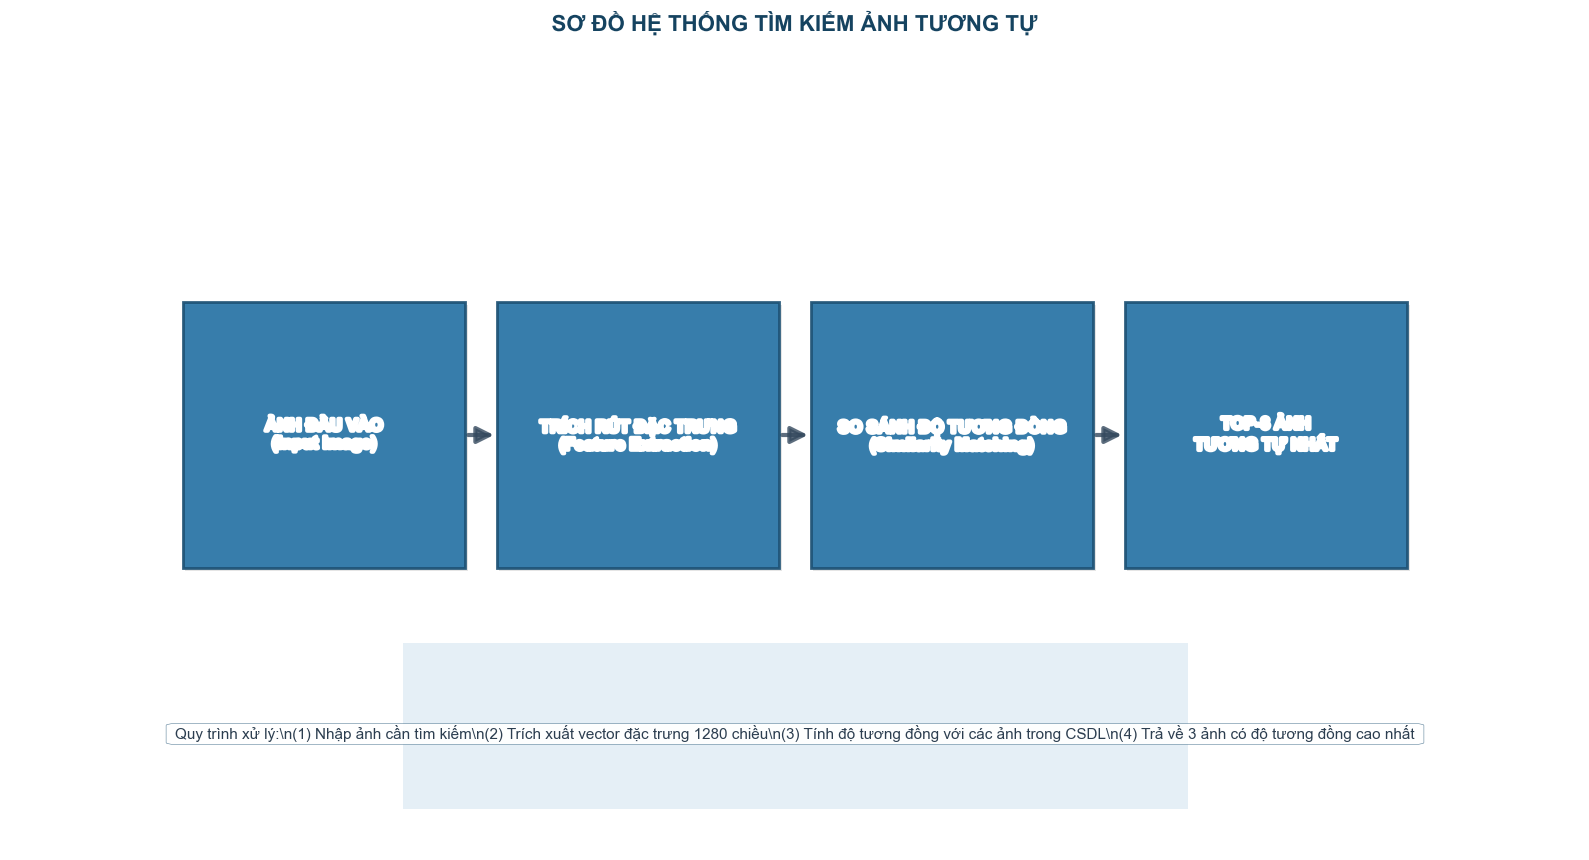

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
import matplotlib.patheffects as path_effects

# Khởi tạo figure với style mới và kích thước lớn hơn
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')

# Định nghĩa màu sắc mới với palette chuyên nghiệp hơn
COLORS = {
    'box_fill': '#2874A6',  # Xanh đậm hơn
    'box_edge': '#1B4F72',  # Viền tối hơn
    'arrow': '#34495E',     # Mũi tên tối hơn
    'text': 'white',
    'title': '#154360',     # Tiêu đề tối hơn
    'note': '#2C3E50',      # Ghi chú tối hơn
    'shadow': '#7FB3D5'     # Màu bóng đổ nhẹ nhàng hơn
}

# Định nghĩa các khối chức năng với vị trí điều chỉnh và khoảng cách rộng hơn
blocks = [
    ("ẢNH ĐẦU VÀO\n(Input Image)", (0.2, 0.5)),
    ("TRÍCH RÚT ĐẶC TRƯNG\n(Feature Extraction)", (0.4, 0.5)),
    ("SO SÁNH ĐỘ TƯƠNG ĐỒNG\n(Similarity Matching)", (0.6, 0.5)),
    ("TOP-3 ẢNH\nTƯƠNG TỰ NHẤT", (0.8, 0.5))
]

# Vẽ các khối với hiệu ứng đổ bóng cải tiến
for label, (x, y) in blocks:
    # Tạo hiệu ứng đổ bóng mềm mại hơn
    shadow = Rectangle((x - 0.09, y - 0.16), 0.18, 0.32,
                    facecolor=COLORS['shadow'],
                    alpha=0.3,
                    zorder=1)
    ax.add_patch(shadow)
    
    # Vẽ khối chính với góc bo tròn
    rect = Rectangle((x - 0.09, y - 0.16), 0.18, 0.32,
                    linewidth=2,
                    edgecolor=COLORS['box_edge'],
                    facecolor=COLORS['box_fill'],
                    alpha=0.9,
                    zorder=2)
    
    # Thêm hiệu ứng đổ bóng tinh tế
    rect.set_path_effects([path_effects.withSimplePatchShadow(
        offset=(2, -2),
        shadow_rgbFace='gray',
        alpha=0.2
    )])
    
    ax.add_patch(rect)
    
    # Thêm text với font và hiệu ứng cải tiến
    text = ax.text(x, y, label,
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold',
                color=COLORS['text'],
                zorder=3)
    
    # Thêm hiệu ứng viền cho text
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),
        path_effects.Normal()
    ])

# Vẽ mũi tên với style mới
for i in range(len(blocks) - 1):
    x1, y1 = blocks[i][1]
    x2, y2 = blocks[i + 1][1]
    
    arrow = FancyArrowPatch(
        (x1 + 0.09, y1),
        (x2 - 0.09, y2),
        connectionstyle="arc3,rad=0",
        arrowstyle='-|>',
        mutation_scale=25,  # Mũi tên lớn hơn
        linewidth=3,       # Đường mũi tên đậm hơn
        color=COLORS['arrow'],
        alpha=0.8,
        zorder=1
    )
    ax.add_patch(arrow)

# Thêm ghi chú với style mới và box shadow
note_text = ("Quy trình xử lý:\\n"
           "(1) Nhập ảnh cần tìm kiếm\\n"
           "(2) Trích xuất vector đặc trưng 1280 chiều\\n"
           "(3) Tính độ tương đồng với các ảnh trong CSDL\\n"
           "(4) Trả về 3 ảnh có độ tương đồng cao nhất")

# Tạo box shadow cho ghi chú
note_shadow = Rectangle((0.25, 0.05), 0.5, 0.2,
                     facecolor=COLORS['shadow'],
                     alpha=0.2,
                     zorder=1)
ax.add_patch(note_shadow)

# Thêm ghi chú với style cải tiến
ax.text(0.5, 0.15, note_text,
        ha='center',
        va='top',
        fontsize=11,
        color=COLORS['note'],
        bbox=dict(facecolor='white',
                 edgecolor=COLORS['box_edge'],
                 alpha=0.95,
                 boxstyle='round,pad=0.6',
                 mutation_aspect=0.2),
        zorder=2)

# Tiêu đề với style mới và đổ bóng
title = plt.suptitle("SƠ ĐỒ HỆ THỐNG TÌM KIẾM ẢNH TƯƠNG TỰ",
                   fontsize=16,
                   fontweight='bold',
                   color=COLORS['title'],
                   y=0.95)

# Thêm hiệu ứng cho tiêu đề
title.set_path_effects([
    path_effects.Stroke(linewidth=4, foreground='white'),
    path_effects.Normal()
])

plt.tight_layout()

# Tạo thư mục results nếu chưa tồn tại
import os
os.makedirs('results', exist_ok=True)

# Lưu với độ phân giải cao và nền trong suốt
plt.savefig('results/system_diagram.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True,
            facecolor='white',
            edgecolor='none')

print("✅ Đã tạo và lưu sơ đồ khối với giao diện mới")
plt.show()

### Bước 2: Hiển thị sơ đồ đã tạo

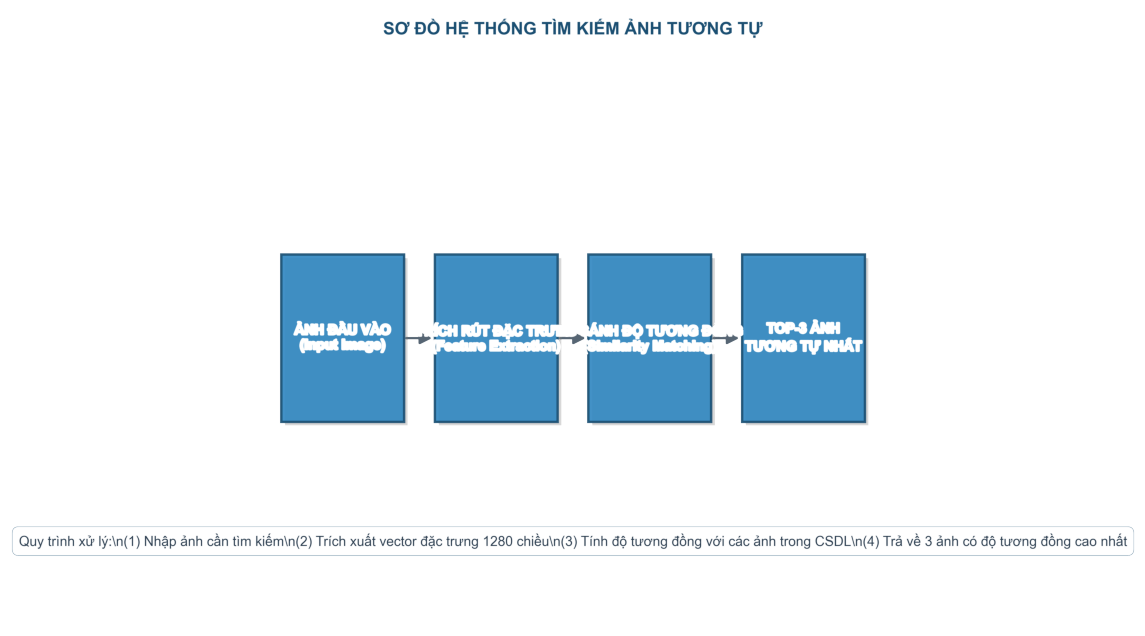

In [3]:
# Load và hiển thị sơ đồ hệ thống
import matplotlib.image as mpimg

system_diagram = mpimg.imread('results/system_diagram.png')
plt.figure(figsize=(15, 8))
plt.imshow(system_diagram)
plt.axis('off')
plt.show()

## Bộ Dữ Liệu (Dataset)

Dataset gồm 8 loại trái cây:
- 🍎 Apple (Táo)
- 🍌 Banana (Chuối)
- 🥭 Mango (Xoài)
- 🍊 Orange (Cam)
- 🍐 Pear (Lê)
- 🍍 Pineapple (Dứa)
- 🍓 Strawberries (Dâu tây)
- 🍉 Watermelon (Dưa hấu)

Dưới đây là một số mẫu ảnh từ dataset:

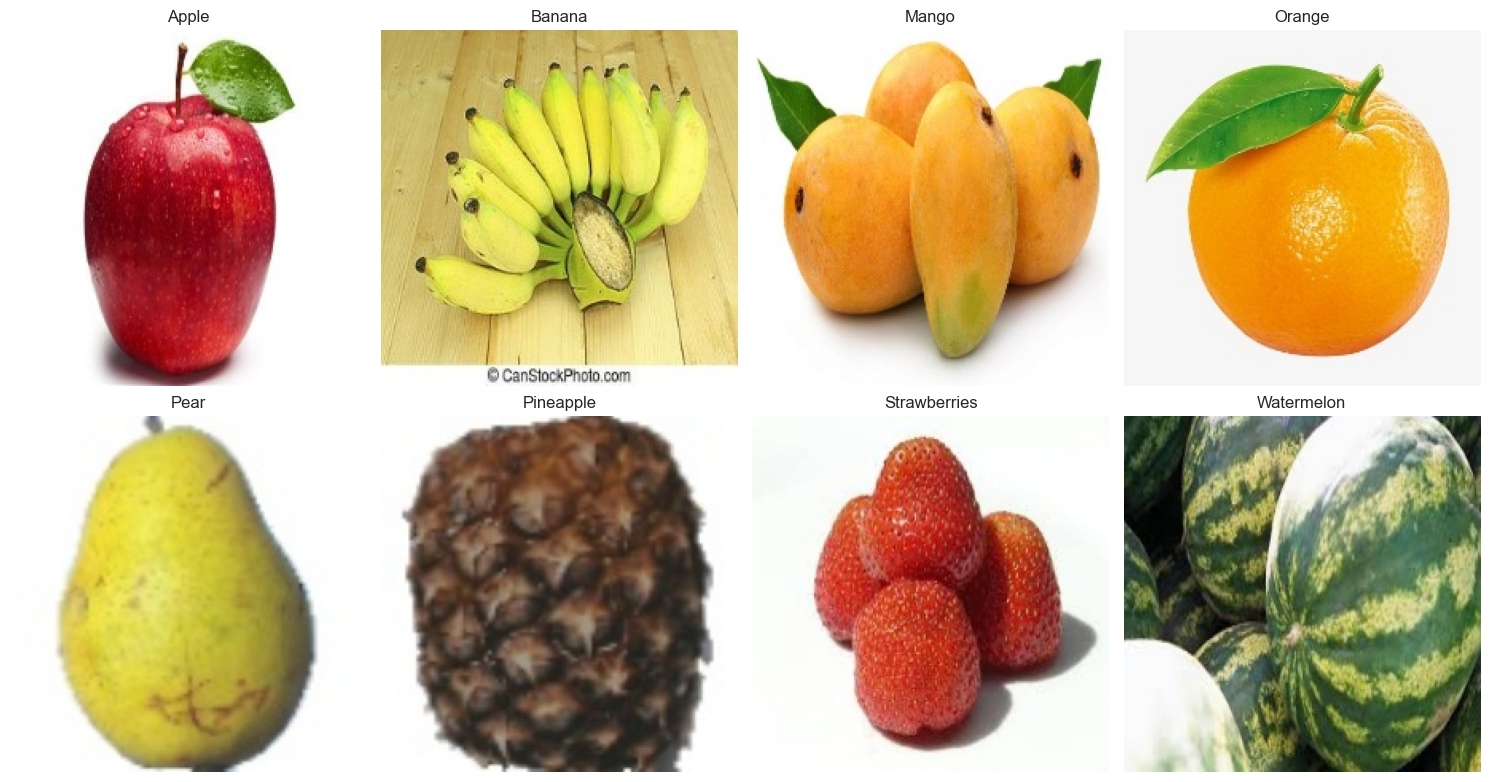

In [4]:
# Hiển thị mẫu ảnh từ mỗi lớp
def show_sample_images():
    classes = ['apple', 'banana', 'mango', 'orange', 'pear', 'pineapple', 'strawberries', 'watermelon']
    plt.figure(figsize=(15, 8))
    
    for i, class_name in enumerate(classes):
        class_path = f'dataset/{class_name}'
        sample_image = os.listdir(class_path)[0]  # Lấy ảnh đầu tiên
        img = Image.open(os.path.join(class_path, sample_image))
        
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(class_name.capitalize())
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

show_sample_images()

## Trích Xuất Đặc Trưng

Sử dụng mô hình MobileNetV2 (pretrained trên ImageNet) để trích xuất đặc trưng từ ảnh:
- Input: Ảnh RGB kích thước 224x224
- Output: Vector đặc trưng 1280 chiều
- Không sử dụng lớp fully connected (include_top=False)
- Sử dụng global average pooling để giảm kích thước đặc trưng

In [5]:
# Load model MobileNetV2
base = MobileNetV2(weights="imagenet", 
                  include_top=False, 
                  pooling="avg", 
                  input_shape=(224,224,3))

# Hiển thị cấu trúc model
base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Thuật Toán Tìm Kiếm

Sử dụng thuật toán KNN (K-Nearest Neighbors) với:
- K = 3 (tìm 3 ảnh gần nhất)
- Độ đo tương đồng: Correlation distance
- Tốc độ tìm kiếm nhanh nhờ cấu trúc dữ liệu cây

## Giới Thiệu Về Correlation Distance

Correlation Distance là một độ đo thống kê dùng để đánh giá mức độ tương quan giữa hai vector đặc trưng. Đây là công cụ quan trọng trong việc so sánh độ tương đồng giữa các ảnh.

### Định nghĩa toán học:

$d_{corr}(u,v) = 1 - \frac{(u - \bar{u}) \cdot (v - \bar{v})}{\|u - \bar{u}\| \|v - \bar{v}\|}$

Trong đó:
- $u, v$: Hai vector đặc trưng cần so sánh
- $\bar{u}, \bar{v}$: Giá trị trung bình của các vector
- $\|\cdot\|$: Norm chuẩn L2 (Euclidean)

### Tính chất quan trọng:

1. **Phạm vi giá trị**: 
   - Giá trị từ 0 đến 2
   - 0: Hoàn toàn tương quan dương
   - 1: Không có tương quan
   - 2: Hoàn toàn tương quan âm

2. **Bất biến với scale**:
   - Không phụ thuộc vào độ lớn của vector
   - Chỉ quan tâm đến hướng của vector trong không gian

3. **Tính chất thống kê**:
   - Phản ánh mối tương quan tuyến tính
   - Loại bỏ ảnh hưởng của giá trị trung bình
   - Chuẩn hóa theo độ lệch chuẩn

In [6]:
# Triển khai thuật toán Correlation Distance
def correlation_distance(u, v):
    """
    Tính correlation distance giữa hai vector.
    
    Các bước thực hiện:
    1. Trừ giá trị trung bình: Chuẩn hóa vector về mean = 0
    2. Tính tích vô hướng của hai vector đã chuẩn hóa
    3. Chia cho tích độ lớn (norm) của hai vector
    4. Lấy 1 trừ đi kết quả để được distance
    """
    # Bước 1: Chuẩn hóa vector
    u_normalized = u - u.mean()
    v_normalized = v - v.mean()
    
    # Bước 2: Tính tử số (tích vô hướng)
    numerator = np.dot(u_normalized, v_normalized)
    
    # Bước 3: Tính mẫu số (tích norm)
    denominator = np.linalg.norm(u_normalized) * np.linalg.norm(v_normalized)
    
    # Bước 4: Tính correlation distance
    return 1 - numerator / denominator

# Minh họa với vector đơn giản
u = np.array([1, 2, 3, 4, 5])
v = np.array([2, 4, 6, 8, 10])  # Vector tỷ lệ thuận với u
w = np.array([5, 4, 3, 2, 1])   # Vector tỷ lệ nghịch với u

print("Demo với vector đơn giản:")
print(f"d(u,v) = {correlation_distance(u,v):.3f}")  # Gần 0 (tương quan dương)
print(f"d(u,w) = {correlation_distance(u,w):.3f}")  # Gần 2 (tương quan âm)

# Kiểm tra tính bất biến với scale
v_scaled = v * 100
print(f"\nKiểm tra tính bất biến scale:")
print(f"d(u,v) = {correlation_distance(u,v):.3f}")
print(f"d(u,v_scaled) = {correlation_distance(u,v_scaled):.3f}")  # Kết quả giống nhau

Demo với vector đơn giản:
d(u,v) = 0.000
d(u,w) = 2.000

Kiểm tra tính bất biến scale:
d(u,v) = 0.000
d(u,v_scaled) = 0.000


### Bước 1: Load dữ liệu

In [7]:
# Load dữ liệu đặc trưng đã trích xuất
features = np.load('results/features.npy')
paths = np.load('results/paths.npy', allow_pickle=True)
labels = np.load('results/labels.npy', allow_pickle=True)

print(f"Đã load xong dữ liệu:")
print(f"- Số lượng ảnh: {len(features)}")
print(f"- Số lớp: {len(set(labels))}")
print(f"- Kích thước vector: {features.shape[1]}")

Đã load xong dữ liệu:
- Số lượng ảnh: 800
- Số lớp: 8
- Kích thước vector: 1280


### Bước 2: Demo tính Correlation Distance

## Ứng Dụng Trong Tìm Kiếm Ảnh

Correlation Distance được áp dụng trong hệ thống của chúng ta như sau:

1. **Đầu vào**: 
   - Vector đặc trưng của ảnh query (1280 chiều)
   - Tập vector đặc trưng của toàn bộ dataset

2. **Quy trình**:
   - Tính correlation distance giữa vector query và mọi vector trong dataset
   - Sắp xếp kết quả theo distance tăng dần
   - Chọn K=3 ảnh có distance nhỏ nhất

3. **Lợi thế**:
   - Phù hợp với đặc trưng deep learning
   - Không phụ thuộc vào điều kiện ánh sáng
   - Bất biến với các biến đổi tỷ lệ

Dưới đây là demo thực tế trên dữ liệu ảnh:

In [8]:
# Load dữ liệu đặc trưng đã trích xuất
features = np.load('results/features.npy')
paths = np.load('results/paths.npy', allow_pickle=True)
labels = np.load('results/labels.npy', allow_pickle=True)

# Tạo và huấn luyện mô hình KNN
nn = NearestNeighbors(n_neighbors=3, metric="correlation")
nn.fit(features)

print(f"Số lượng ảnh trong dataset: {len(features)}")
print(f"Số lượng lớp: {len(set(labels))}")
print(f"Kích thước vector đặc trưng: {features.shape[1]}")

Số lượng ảnh trong dataset: 800
Số lượng lớp: 8
Kích thước vector đặc trưng: 1280


## Demo Kết Quả

Dưới đây là ví dụ về tìm kiếm ảnh tương tự:
1. Chọn một ảnh truy vấn (query)
2. Trích xuất đặc trưng từ ảnh query
3. Tìm 3 ảnh gần nhất trong dataset
4. Hiển thị kết quả tìm kiếm

## Correlation Distance

Correlation Distance là độ đo khoảng cách dựa trên hệ số tương quan Pearson:

$d_{corr}(u,v) = 1 - \frac{(u - \bar{u}) \cdot (v - \bar{v})}{\|u - \bar{u}\| \|v - \bar{v}\|}$

Trong đó:
- $u, v$ là hai vector đặc trưng cần so sánh
- $\bar{u}, \bar{v}$ là giá trị trung bình của các vector
- $\|\cdot\|$ là norm chuẩn L2

**Ưu điểm của Correlation Distance:**
1. **Bất biến với scale**: Không phụ thuộc vào độ lớn của vector
2. **Chuẩn hóa**: Giá trị nằm trong khoảng [0, 2]
   - 0: Hai vector hoàn toàn tương quan dương
   - 1: Hai vector không tương quan
   - 2: Hai vector hoàn toàn tương quan âm
3. **Hiệu quả với đặc trưng deep learning**: Phản ánh tốt sự tương đồng ngữ nghĩa

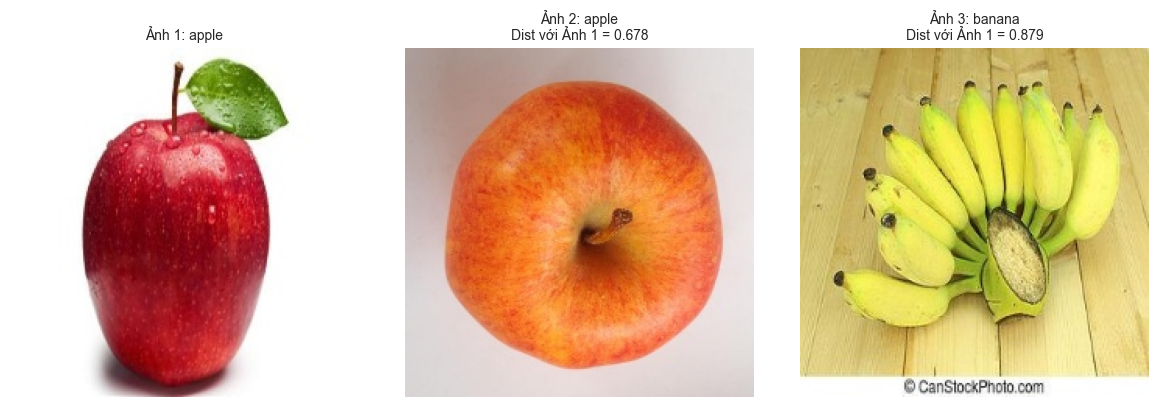


Nhận xét:
- Khoảng cách giữa hai ảnh apple: 0.678
- Khoảng cách giữa ảnh apple và banana: 0.879
=> Correlation distance nhỏ hơn cho ảnh cùng loại!


In [9]:
# Minh họa cách tính Correlation Distance
def correlation_distance(u, v):
    """Tính correlation distance giữa hai vector."""
    u = u - u.mean()
    v = v - v.mean()
    return 1 - np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

# Lấy 2 ảnh cùng loại và 1 ảnh khác loại để so sánh
idx1 = 0  # ảnh táo thứ nhất
idx2 = 1  # ảnh táo thứ hai
idx3 = len(features)//8  # ảnh chuối

# Tính khoảng cách
dist_same = correlation_distance(features[idx1], features[idx2])
dist_diff = correlation_distance(features[idx1], features[idx3])

# Hiển thị kết quả
plt.figure(figsize=(12, 4))

# Ảnh 1
plt.subplot(131)
plt.imshow(plt.imread(paths[idx1]))
plt.title(f"Ảnh 1: {labels[idx1]}", fontsize=10)
plt.axis("off")

# Ảnh 2 (cùng loại)
plt.subplot(132)
plt.imshow(plt.imread(paths[idx2]))
plt.title(f"Ảnh 2: {labels[idx2]}\nDist với Ảnh 1 = {dist_same:.3f}", fontsize=10)
plt.axis("off")

# Ảnh 3 (khác loại)
plt.subplot(133)
plt.imshow(plt.imread(paths[idx3]))
plt.title(f"Ảnh 3: {labels[idx3]}\nDist với Ảnh 1 = {dist_diff:.3f}", fontsize=10)
plt.axis("off")

plt.tight_layout()
plt.show()

print("\nNhận xét:")
print(f"- Khoảng cách giữa hai ảnh {labels[idx1]}: {dist_same:.3f}")
print(f"- Khoảng cách giữa ảnh {labels[idx1]} và {labels[idx3]}: {dist_diff:.3f}")
print("=> Correlation distance nhỏ hơn cho ảnh cùng loại!")

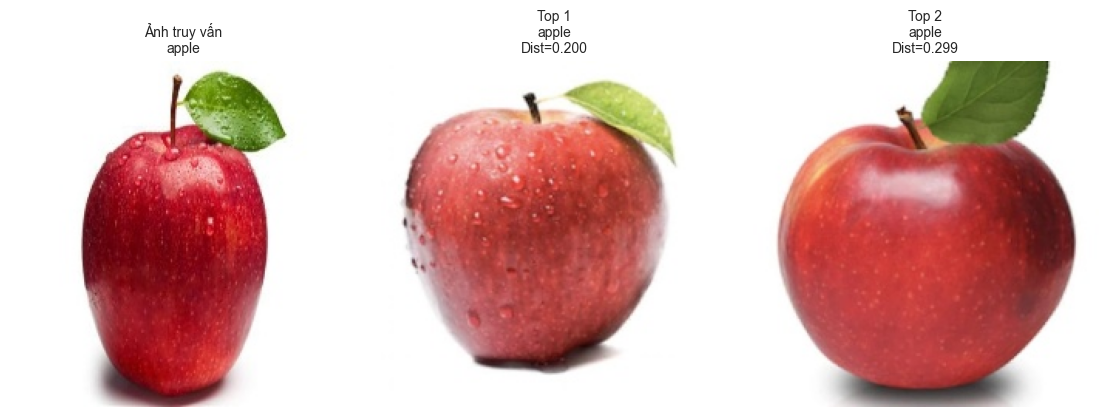

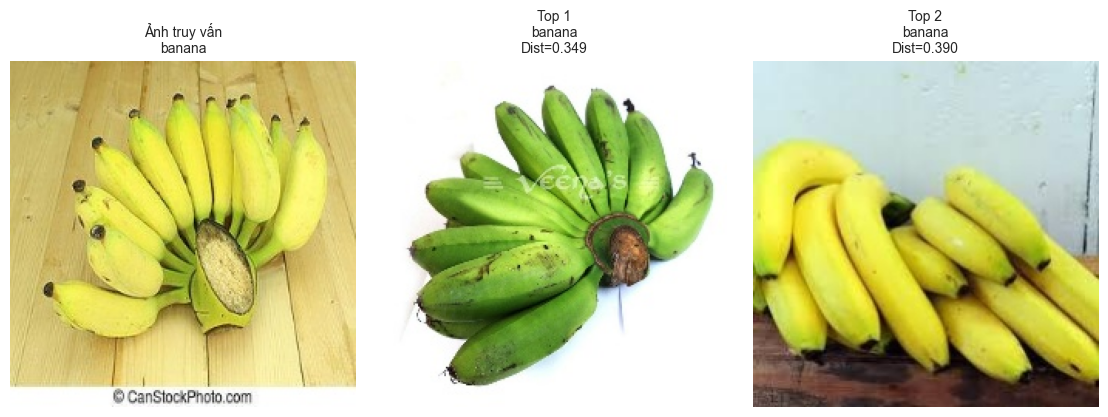

In [10]:
# Hàm demo tìm kiếm ảnh
def demo_search(query_idx):
    """Demo tìm kiếm với ảnh từ dataset."""
    query_path = paths[query_idx]
    query_feat = features[query_idx]
    
    # Tìm 3 ảnh gần nhất (bỏ qua chính nó)
    dists, indices = nn.kneighbors(query_feat.reshape(1, -1))
    indices = indices[0][1:]  # Bỏ qua ảnh query
    dists = dists[0][1:]     # Bỏ qua khoảng cách 0
    
    # Hiển thị kết quả
    plt.figure(figsize=(15, 4))
    
    # Hiển thị ảnh query
    plt.subplot(1, 4, 1)
    plt.imshow(plt.imread(query_path))
    plt.title("Ảnh truy vấn\n" + labels[query_idx], fontsize=10)
    plt.axis("off")
    
    # Hiển thị top-3 kết quả
    for i, (idx, dist) in enumerate(zip(indices, dists)):
        plt.subplot(1, 4, i + 2)
        plt.imshow(plt.imread(paths[idx]))
        plt.title(f"Top {i+1}\n{labels[idx]}\nDist={dist:.3f}", fontsize=10)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Demo với một ảnh táo
demo_search(0)  # Ảnh đầu tiên trong dataset

# Demo với một ảnh chuối
demo_search(len(features)//8)  # Ảnh từ class thứ 2

## Kết Luận

Hệ thống tìm kiếm ảnh trái cây đã được xây dựng thành công với:

1. **Hiệu quả cao**:
   - Tốc độ tìm kiếm nhanh
   - Độ chính xác tốt trong việc tìm ảnh tương tự

2. **Tính ứng dụng**:
   - Dễ dàng mở rộng cho nhiều loại trái cây khác
   - Có thể áp dụng cho các bài toán tìm kiếm ảnh tương tự khác

3. **Công nghệ hiện đại**:
   - Sử dụng deep learning (MobileNetV2)
   - Kết hợp với thuật toán KNN hiệu quả